In [22]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.rcParams.update({'figure.dpi':110, 'font.size':11,
                     'axes.spines.top':False, 'axes.spines.right':False})
sns.set_palette("husl")

np.random.seed(42)

print("="*70)
print("EV CHARGING DEMAND FORECASTING - EXPLORATORY DATA ANALYSIS")
print("="*70)
print("✓ Libraries and setup complete\n")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
EV CHARGING DEMAND FORECASTING - EXPLORATORY DATA ANALYSIS
✓ Libraries and setup complete



In [23]:
# Load data from Google Drive
DATA_PATH = '/content/drive/MyDrive/MRP_EV/ev_charging_station_data_100k.csv'
df = pd.read_csv(DATA_PATH, parse_dates=['timestamp'])

print("DATA OVERVIEW")
print("="*70)
print(f"Total records: {len(df):,}")
print(f"Time range: {df['timestamp'].min().date()} to {df['timestamp'].max().date()}")
print(f"Duration: {(df['timestamp'].max() - df['timestamp'].min()).days} days")
print(f"\nStations: {df['station_id'].nunique()}")
print(f"Cities: {df['city'].nunique()}")
print(f"Networks: {df.network.nunique()}")
print(f"Charger types: {df['charger_type'].nunique()}")

print(f"\nColumns: {len(df.columns)}")
print(f"Missing values: {df.isna().sum().sum()} (0% - clean dataset ✓)")

print("\n" + "="*70)

DATA OVERVIEW
Total records: 100,000
Time range: 2025-07-01 to 2025-12-31
Duration: 183 days

Stations: 12
Cities: 7
Networks: 6
Charger types: 3

Columns: 33
Missing values: 0 (0% - clean dataset ✓)



UTILIZATION RATE DISTRIBUTION
Min: 0.020 | Max: 0.980
Mean: 0.397 | Median: 0.377
Std Dev: 0.302
Percentiles:
  10th: 0.029
  25th: 0.105
  50th: 0.377
  75th: 0.636
  90th: 0.838


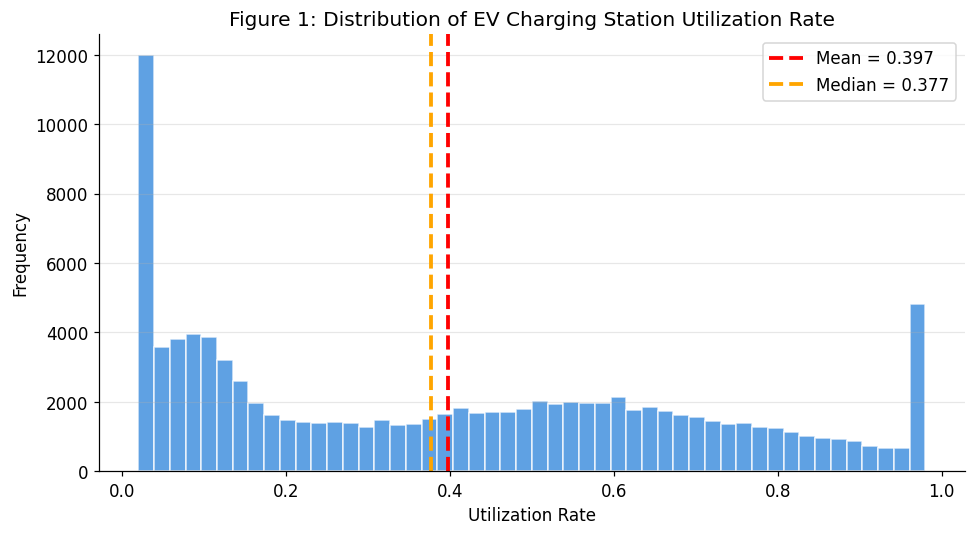

In [24]:
print("UTILIZATION RATE DISTRIBUTION")
print("="*70)

# Statistics
util = df['utilization_rate']
print(f"Min: {util.min():.3f} | Max: {util.max():.3f}")
print(f"Mean: {util.mean():.3f} | Median: {util.median():.3f}")
print(f"Std Dev: {util.std():.3f}")
print(f"Percentiles:")
print(f"  10th: {util.quantile(0.1):.3f}")
print(f"  25th: {util.quantile(0.25):.3f}")
print(f"  50th: {util.quantile(0.5):.3f}")
print(f"  75th: {util.quantile(0.75):.3f}")
print(f"  90th: {util.quantile(0.9):.3f}")

# Histogram
fig, ax = plt.subplots(figsize=(9,5))
ax.hist(df['utilization_rate'], bins=50, color='#378ADD', edgecolor='white', alpha=0.8)
ax.axvline(df['utilization_rate'].mean(), color='red', ls='--', lw=2.5, label=f'Mean = {util.mean():.3f}')
ax.axvline(df['utilization_rate'].median(), color='orange', ls='--', lw=2.5, label=f'Median = {util.median():.3f}')
ax.set(xlabel='Utilization Rate', ylabel='Frequency',
       title='Figure 1: Distribution of EV Charging Station Utilization Rate')
ax.legend()
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("="*70 + "\n")

HOURLY DEMAND PATTERN
              mean    std  count
hour_of_day                     
0.0          0.155  0.108   4179
1.0          0.110  0.100   4168
2.0          0.081  0.089   4167
3.0          0.066  0.077   4166
4.0          0.065  0.071   4166
5.0          0.083  0.052   4166
6.0          0.138  0.073   4166
7.0          0.279  0.135   4166
8.0          0.436  0.208   4166
9.0          0.518  0.234   4166
10.0         0.582  0.247   4166
11.0         0.635  0.255   4166
12.0         0.655  0.256   4166
13.0         0.628  0.255   4166
14.0         0.595  0.244   4166
15.0         0.576  0.230   4166
16.0         0.569  0.219   4166
17.0         0.602  0.240   4166
18.0         0.610  0.279   4166
19.0         0.606  0.303   4166
20.0         0.539  0.296   4166
21.0         0.453  0.266   4166
22.0         0.328  0.201   4166
23.0         0.226  0.140   4166


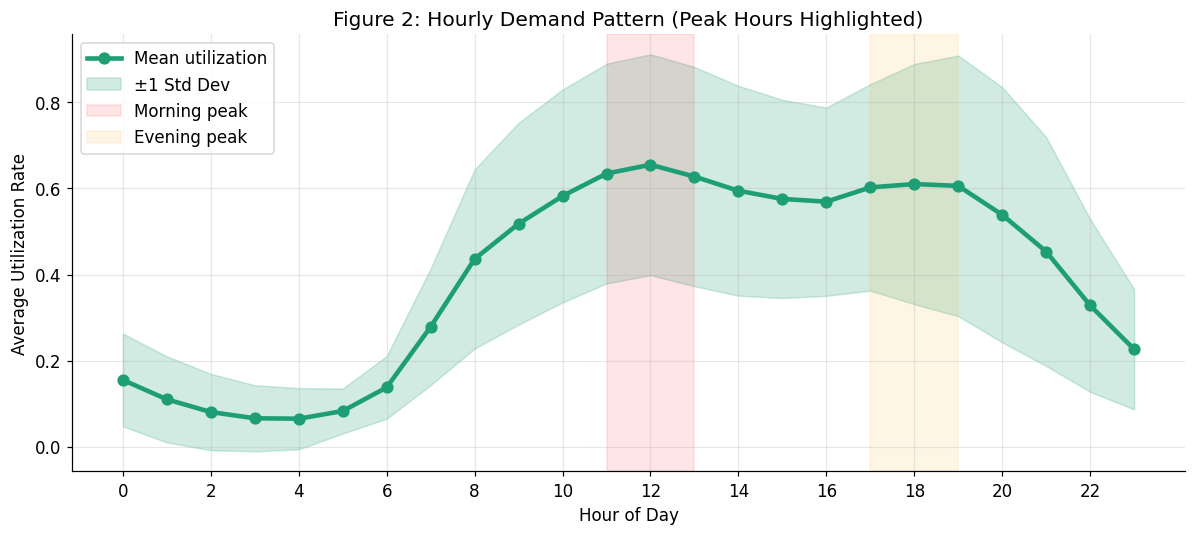


📊 KEY FINDINGS:
   Busiest hour: 12:00 (utilization 0.655)
   Quietest hour: 4:00 (utilization 0.065)
   Variation: 0.590



In [25]:
print("HOURLY DEMAND PATTERN")
print("="*70)

hourly = df.groupby('hour_of_day')['utilization_rate'].agg(['mean', 'std', 'count'])
print(hourly.round(3))

# Chart
fig, ax = plt.subplots(figsize=(11,5))
ax.plot(hourly.index, hourly['mean'], marker='o', color='#1D9E75', lw=3, markersize=7, label='Mean utilization')
ax.fill_between(hourly.index,
                hourly['mean'] - hourly['std'],
                hourly['mean'] + hourly['std'],
                alpha=0.2, color='#1D9E75', label='±1 Std Dev')
ax.axvspan(11, 13, alpha=0.1, color='red', label='Morning peak')
ax.axvspan(17, 19, alpha=0.1, color='orange', label='Evening peak')
ax.set(xlabel='Hour of Day', ylabel='Average Utilization Rate',
       title='Figure 2: Hourly Demand Pattern (Peak Hours Highlighted)',
       xticks=range(0, 24, 2))
ax.grid(alpha=0.3)
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

peak_hour = hourly['mean'].idxmax()
low_hour = hourly['mean'].idxmin()
print(f"\n📊 KEY FINDINGS:")
print(f"   Busiest hour: {int(peak_hour)}:00 (utilization {hourly.loc[peak_hour, 'mean']:.3f})")
print(f"   Quietest hour: {int(low_hour)}:00 (utilization {hourly.loc[low_hour, 'mean']:.3f})")
print(f"   Variation: {(hourly['mean'].max() - hourly['mean'].min()):.3f}")
print("="*70 + "\n")

DEMAND BY DAY OF WEEK
            mean    std  count
Monday     0.409  0.297  14208
Tuesday    0.409  0.297  14741
Wednesday  0.406  0.296  14219
Thursday   0.407  0.296  14208
Friday     0.407  0.296  14208
Saturday   0.372  0.313  14208
Sunday     0.371  0.312  14208


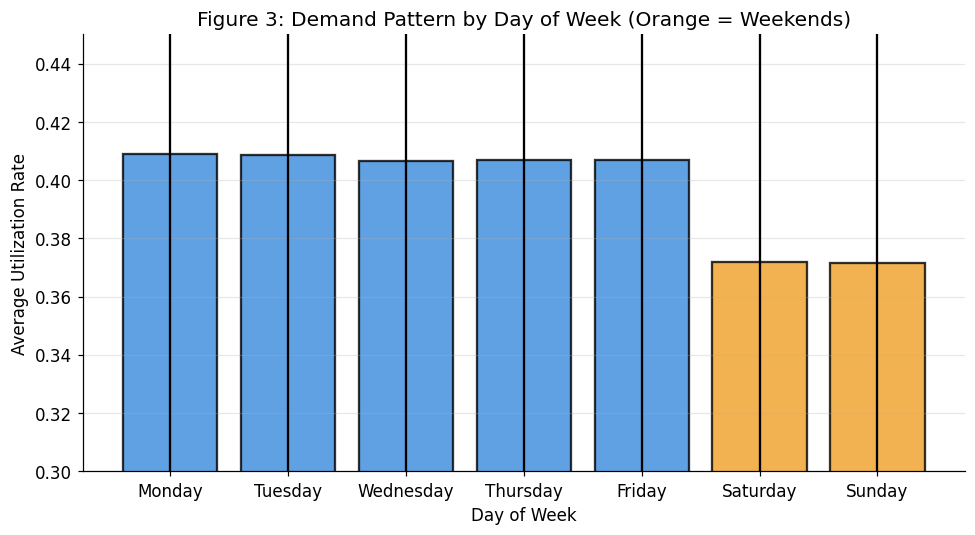


📊 KEY FINDINGS:
   Weekday average: 0.408
   Weekend average: 0.372
   Difference: 0.036 (9.7% higher on weekdays)



In [26]:
print("DEMAND BY DAY OF WEEK")
print("="*70)

dow_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily = df.groupby('day_of_week')['utilization_rate'].agg(['mean', 'std', 'count'])
daily.index = dow_names

print(daily.round(3))

# Chart
fig, ax = plt.subplots(figsize=(9,5))
colors = ['#378ADD']*5 + ['#EF9F27']*2  # Blue for weekdays, orange for weekends
bars = ax.bar(range(7), daily['mean'], color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax.errorbar(range(7), daily['mean'], yerr=daily['std'], fmt='none', color='black', capsize=5, capthick=2)
ax.set(xlabel='Day of Week', ylabel='Average Utilization Rate',
       title='Figure 3: Demand Pattern by Day of Week (Orange = Weekends)',
       xticks=range(7), xticklabels=dow_names, ylim=[0.3, 0.45])
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

weekday_avg = df[~df['is_weekend']]['utilization_rate'].mean()
weekend_avg = df[df['is_weekend']]['utilization_rate'].mean()
print(f"\n📊 KEY FINDINGS:")
print(f"   Weekday average: {weekday_avg:.3f}")
print(f"   Weekend average: {weekend_avg:.3f}")
print(f"   Difference: {(weekday_avg - weekend_avg):.3f} ({100*(weekday_avg/weekend_avg - 1):.1f}% higher on weekdays)")
print("="*70 + "\n")

WEEKDAY VS WEEKEND HOURLY PATTERNS


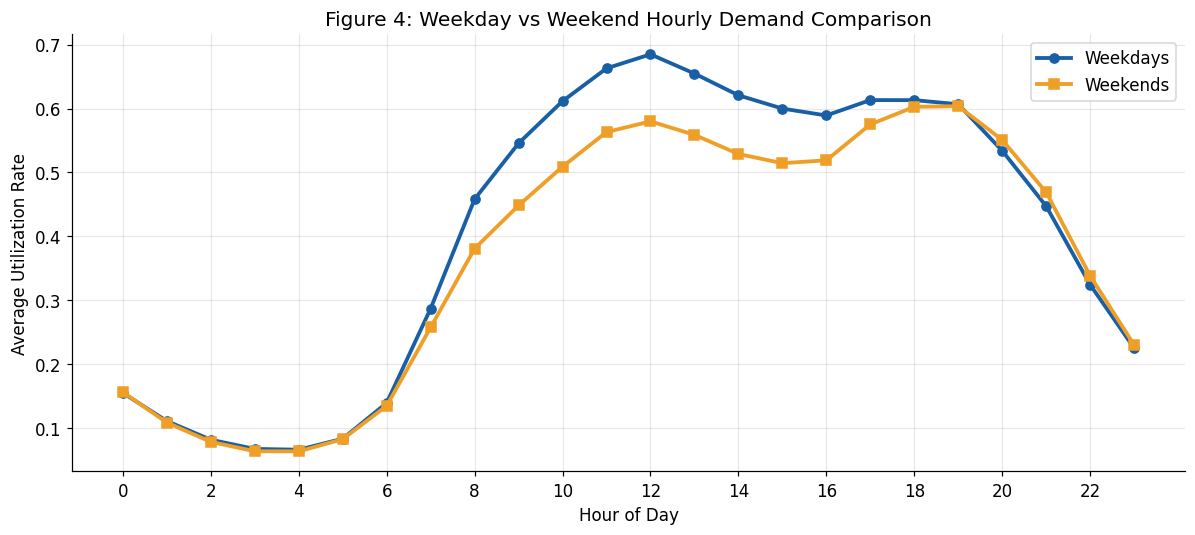

Weekday peak: 0.685 at hour 12:00
Weekend peak: 0.604 at hour 19:00



In [27]:
print("WEEKDAY VS WEEKEND HOURLY PATTERNS")
print("="*70)

weekday_hourly = df[~df['is_weekend']].groupby('hour_of_day')['utilization_rate'].mean()
weekend_hourly = df[df['is_weekend']].groupby('hour_of_day')['utilization_rate'].mean()

# Chart
fig, ax = plt.subplots(figsize=(11,5))
ax.plot(weekday_hourly.index, weekday_hourly.values, marker='o', color='#185FA5',
        lw=2.5, label='Weekdays', markersize=6)
ax.plot(weekend_hourly.index, weekend_hourly.values, marker='s', color='#EF9F27',
        lw=2.5, label='Weekends', markersize=6)
ax.set(xlabel='Hour of Day', ylabel='Average Utilization Rate',
       title='Figure 4: Weekday vs Weekend Hourly Demand Comparison',
       xticks=range(0, 24, 2))
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Weekday peak: {weekday_hourly.max():.3f} at hour {weekday_hourly.idxmax():.0f}:00")
print(f"Weekend peak: {weekend_hourly.max():.3f} at hour {weekend_hourly.idxmax():.0f}:00")
print("="*70 + "\n")

DEMAND TREND OVER 6 MONTHS


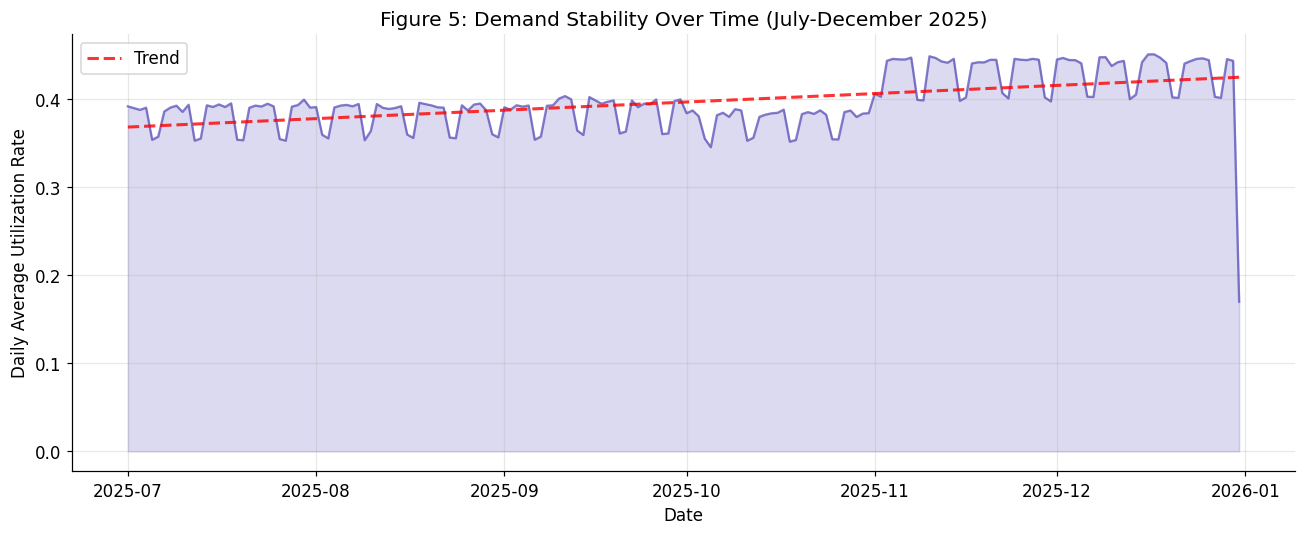

Mean daily utilization: 0.397
Trend slope: 0.000309 (daily change)
✓ Demand is STABLE - no significant upward/downward trend



In [28]:
print("DEMAND TREND OVER 6 MONTHS")
print("="*70)

daily_data = df.set_index('timestamp')['utilization_rate'].resample('D').mean()

# Chart
fig, ax = plt.subplots(figsize=(12,5))
ax.plot(daily_data.index, daily_data.values, color='#534AB7', lw=1.5, alpha=0.7)
ax.fill_between(daily_data.index, daily_data.values, alpha=0.2, color='#534AB7')

# Add trend line
z = np.polyfit(range(len(daily_data)), daily_data.values, 1)
p = np.poly1d(z)
ax.plot(daily_data.index, p(range(len(daily_data))), "r--", lw=2, label='Trend', alpha=0.8)

ax.set(xlabel='Date', ylabel='Daily Average Utilization Rate',
       title='Figure 5: Demand Stability Over Time (July-December 2025)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Mean daily utilization: {daily_data.mean():.3f}")
print(f"Trend slope: {z[0]:.6f} (daily change)")
if abs(z[0]) < 0.001:
    print("✓ Demand is STABLE - no significant upward/downward trend")
print("="*70 + "\n")

PEAK-LOAD-RISK WINDOWS: HOUR × DAY HEATMAP


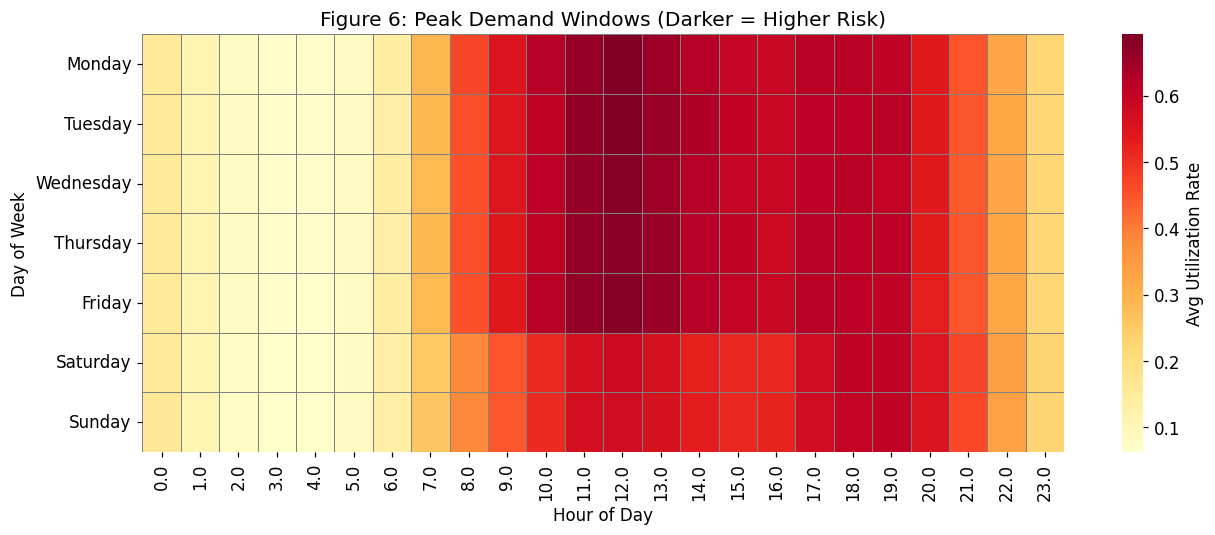


High-risk threshold (75th percentile): 0.604

HIGHEST RISK PERIODS:
  Monday, 10:00 → 0.617
  Monday, 11:00 → 0.660
  Monday, 12:00 → 0.692
  Monday, 13:00 → 0.655
  Monday, 14:00 → 0.621
  Monday, 17:00 → 0.616
  Monday, 18:00 → 0.614
  Monday, 19:00 → 0.604
  Tuesday, 10:00 → 0.608
  Tuesday, 11:00 → 0.666
  Tuesday, 12:00 → 0.688
  Tuesday, 13:00 → 0.655
  Tuesday, 14:00 → 0.630
  Tuesday, 17:00 → 0.612
  Tuesday, 18:00 → 0.612
  Tuesday, 19:00 → 0.614
  Wednesday, 10:00 → 0.612
  Wednesday, 11:00 → 0.662
  Wednesday, 12:00 → 0.683
  Wednesday, 13:00 → 0.651
  Wednesday, 14:00 → 0.619
  Wednesday, 17:00 → 0.610
  Wednesday, 18:00 → 0.614
  Thursday, 10:00 → 0.607
  Thursday, 11:00 → 0.662
  Thursday, 12:00 → 0.677
  Thursday, 13:00 → 0.656
  Thursday, 14:00 → 0.617
  Thursday, 15:00 → 0.606
  Thursday, 17:00 → 0.615
  Thursday, 18:00 → 0.613
  Thursday, 19:00 → 0.610
  Friday, 10:00 → 0.614
  Friday, 11:00 → 0.664
  Friday, 12:00 → 0.684
  Friday, 13:00 → 0.657
  Friday, 14:00 → 0.

In [29]:
print("PEAK-LOAD-RISK WINDOWS: HOUR × DAY HEATMAP")
print("="*70)

piv = df.pivot_table(index='day_of_week', columns='hour_of_day',
                     values='utilization_rate', aggfunc='mean')
piv.index = dow_names

# Chart
fig, ax = plt.subplots(figsize=(12,5))
sns.heatmap(piv, cmap='YlOrRd', ax=ax, cbar_kws={'label':'Avg Utilization Rate'},
            annot=False, linewidths=0.5, linecolor='gray')
ax.set(xlabel='Hour of Day', ylabel='Day of Week',
       title='Figure 6: Peak Demand Windows (Darker = Higher Risk)')
plt.tight_layout()
plt.show()

# Find peak windows
peak_threshold = piv.values.flatten()
peak_threshold = np.percentile(peak_threshold, 75)  # Top 25%
print(f"\nHigh-risk threshold (75th percentile): {peak_threshold:.3f}")
print("\nHIGHEST RISK PERIODS:")
for day in range(7):
    for hour in range(24):
        if piv.iloc[day, hour] >= peak_threshold:
            print(f"  {dow_names[day]}, {int(hour):2d}:00 → {piv.iloc[day, hour]:.3f}")

print("="*70 + "\n")

DEMAND BY CITY/LOCATION
              mean    std  count
city                            
Phoenix      0.321  0.331  26355
Seattle      0.344  0.273   8785
Atlanta      0.355  0.236  12150
Minneapolis  0.381  0.239  26355
San Diego    0.485  0.267   8785
Austin       0.518  0.306   8785
Los Angeles  0.580  0.374   8785


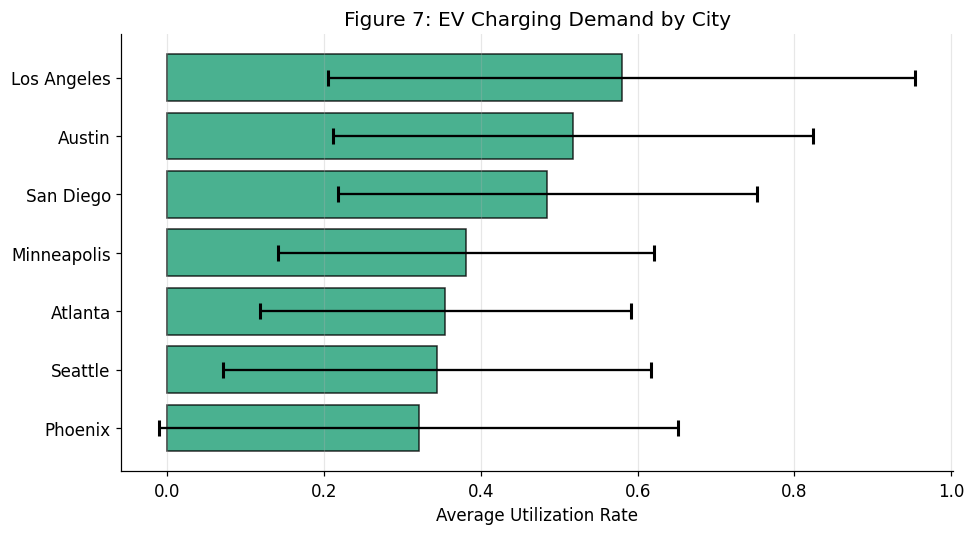


Busiest city: Los Angeles (0.580)
Quietest city: Phoenix (0.321)



In [30]:
print("DEMAND BY CITY/LOCATION")
print("="*70)

city_stats = df.groupby('city')['utilization_rate'].agg(['mean', 'std', 'count']).sort_values('mean', ascending=True)
print(city_stats.round(3))

# Chart
fig, ax = plt.subplots(figsize=(9,5))
bars = ax.barh(city_stats.index, city_stats['mean'], color='#1D9E75', alpha=0.8, edgecolor='black')
ax.errorbar(city_stats['mean'], range(len(city_stats)),
            xerr=city_stats['std'], fmt='none', color='black', capsize=5, capthick=2)
ax.set(xlabel='Average Utilization Rate',
       title='Figure 7: EV Charging Demand by City')
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print(f"\nBusiest city: {city_stats['mean'].idxmax()} ({city_stats['mean'].max():.3f})")
print(f"Quietest city: {city_stats['mean'].idxmin()} ({city_stats['mean'].min():.3f})")
print("="*70 + "\n")

CORRELATION ANALYSIS: WHAT DRIVES DEMAND?
Correlation with utilization_rate (strongest first):
  hour_of_day                   : +0.455
  traffic_congestion_index      : +0.416
  gas_price_per_gallon          : +0.189
  temperature_f                 : -0.010
  precipitation_mm              : -0.015
  current_price                 : -0.132


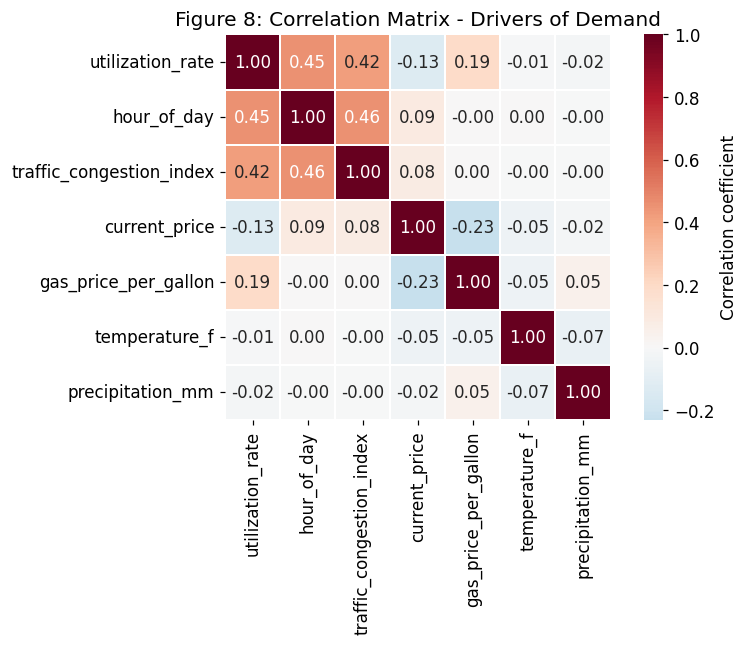


📊 KEY INSIGHTS:
   Strongest driver: hour_of_day (+0.455)
   Second strongest: traffic_congestion_index (+0.416)
   Price sensitivity: -0.132 (weakly negative)

✓ EXPLORATORY DATA ANALYSIS COMPLETE

Key Findings Summary:
  • Clear daily double-peak pattern (noon & evening)
  • Weekday demand ~10% higher than weekends
  • Peak-load-risk window: Weekday 11AM-7PM
  • Demand is stable across 6 months (no trend)
  • Hour of day and traffic are strongest demand drivers


In [31]:
print("CORRELATION ANALYSIS: WHAT DRIVES DEMAND?")
print("="*70)

# Select relevant columns
corr_cols = ['utilization_rate', 'hour_of_day', 'traffic_congestion_index',
             'current_price', 'gas_price_per_gallon', 'temperature_f', 'precipitation_mm']
corr_data = df[corr_cols].corr()

print("Correlation with utilization_rate (strongest first):")
corr_with_util = corr_data['utilization_rate'].drop('utilization_rate').sort_values(ascending=False)
for var, corr_val in corr_with_util.items():
    print(f"  {var:30s}: {corr_val:+.3f}")

# Heatmap
fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(corr_data, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax,
            cbar_kws={'label':'Correlation coefficient'}, square=True, linewidths=1)
ax.set(title='Figure 8: Correlation Matrix - Drivers of Demand')
plt.tight_layout()
plt.show()

print("\n📊 KEY INSIGHTS:")
print(f"   Strongest driver: hour_of_day ({corr_with_util['hour_of_day']:+.3f})")
print(f"   Second strongest: traffic_congestion_index ({corr_with_util['traffic_congestion_index']:+.3f})")
print(f"   Price sensitivity: {corr_with_util['current_price']:+.3f} (weakly negative)")
print("="*70)

print("\n" + "="*70)
print("✓ EXPLORATORY DATA ANALYSIS COMPLETE")
print("="*70)
print("\nKey Findings Summary:")
print("  • Clear daily double-peak pattern (noon & evening)")
print("  • Weekday demand ~10% higher than weekends")
print("  • Peak-load-risk window: Weekday 11AM-7PM")
print("  • Demand is stable across 6 months (no trend)")
print("  • Hour of day and traffic are strongest demand drivers")